In [ ]:
#pip install google-cloud-bigquery pandas
#pip install db-dtypes
#pip install --upgrade tensorflow

In [1]:
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd

credentials = service_account.Credentials.from_service_account_file(
    "chave.json"
)



client = bigquery.Client(credentials=credentials, project=credentials.project_id)


In [2]:
query = """
SELECT *
FROM `local-bliss-359814.ML.df_data_20260328`
"""

df = client.query(query).to_dataframe()
print(df.head())

C:\Users\kevi\AppData\Roaming\Python\Python314\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


                 datahora  previsao    hi_temp  out_hum  wind_speed  wind_dir  \
0 1970-01-19 06:17:16.800      0.16   0.000000      0.0         0.0       0.0   
1 1970-01-19 06:17:20.400      0.18  26.500000     85.0         0.0       0.0   
2 1970-01-19 06:17:24.000      0.17  26.200001     89.0         0.0       0.0   
3 1970-01-19 06:17:27.600      0.14  25.200001     89.0         7.8       0.0   
4 1970-01-19 06:17:31.200      0.13  24.700001     89.0         8.7       0.0   

   vento_num          bar  fase_lua  direcao_6m_deg  ...  altura_mare  \
0        0.0     0.000000       0.5             7.0  ...         0.15   
1       14.0  1004.000000       0.5             7.0  ...         0.15   
2       14.0  1003.900024       0.5             8.0  ...         0.20   
3       12.0  1003.400024       0.5            10.0  ...         0.20   
4       13.0  1003.599976       0.5             2.0  ...         0.15   

   CACHOEIRA DO SUL     CANOAS  GRAVATAI  NOVO HAMBURGO  PORTO ALEGRE  \
0

In [ ]:
df.to_csv("xtrain_horario_t_2026.csv", index=False)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# =========================
# PREPROCESSAMENTO EM df
# =========================

df = df.copy()

# drop coluna
df = df.drop(columns=['temp_out'], errors='ignore')

df = df.drop(columns=['wind_dir'], errors='ignore')
# =========================
# converter tudo para numérico
# =========================

df = df.apply(pd.to_numeric, errors='coerce')

# opcional: limpar NaN gerado pelo map
df = df.fillna(0)


# PREPROCESSAMENTO EM df
# =========================

df = df.copy()

# drop coluna
df = df.drop(columns=['temp_out'], errors='ignore')


# =========================
# converter tudo para numérico
# =========================

df = df.apply(pd.to_numeric, errors='coerce')

# opcional: limpar NaN gerado pelo map
df = df.fillna(0)

# =========================
# datahora -> datetime
# =========================

if 'datahora' in df.columns:
    df['datahora'] = pd.to_datetime(df['datahora'], errors='coerce')

# se datahora for index
if df.index.name == 'datahora':
    df.index = pd.to_datetime(df.index, errors='coerce')

# =========================
# tudo -> numérico (exceto datahora)
# =========================

cols_to_convert = df.columns.drop('datahora', errors='ignore')

df[cols_to_convert] = df[cols_to_convert].apply(
    pd.to_numeric, errors='coerce'
)

# =========================
# substituir erros por 0
# =========================

df[cols_to_convert] = df[cols_to_convert].fillna(0)

# opcional: garantir tipo float32 (mais leve)
df[cols_to_convert] = df[cols_to_convert].astype(np.float32)

df = df.sort_values("datahora").reset_index(drop=True)

# =========================
# TARGET (y) com lead +2
# =========================
y = df[["intensidade_3m_kt"]].shift(-2) # , "direcao_3m_deg"

# =========================
# FEATURES (X_o)
# =========================

# colunas
target_cols = ["intensidade_3m_kt"] # , "direcao_3m_deg"

# variáveis de correnteza (não usar no futuro)
corrente_cols = [c for c in df.columns if "intensidade" in c or "direcao" in c]

# todas exceto datahora
base_cols = [c for c in df.columns if c != "datahora"]

X_parts = []

# ---------
# LAGS (t, t-1, t-2)
# tudo incluso
# ---------
for lag in range(0, 6):
    X_lag = df[base_cols].shift(lag)
    X_lag.columns = [f"{c}_lag{lag}" for c in base_cols]
    X_parts.append(X_lag)

# ---------
# LEADS (t+1 ... t+6)
# exclui correnteza
# ---------
lead_cols = [c for c in base_cols if c not in corrente_cols]

for lead in range(1, 7):
    X_lead = df[lead_cols].shift(-lead)
    X_lead.columns = [f"{c}_lead{lead}" for c in lead_cols]
    X_parts.append(X_lead)

# concatena tudo
X_o = pd.concat(X_parts, axis=1)

# =========================
# LIMPEZA FINAL
# =========================
data = pd.concat([X_o, y], axis=1).dropna()


# remove linhas onde intensidade == 0
data = data[data["intensidade_3m_kt"] != 0]

X_o = data[X_o.columns]
y = data[y.columns]

In [5]:
print(df.dtypes)
print(df.isna().sum().sum())  

datahora                     datetime64[ns]
previsao                            float32
hi_temp                             float32
out_hum                             float32
wind_speed                          float32
vento_num                           float32
bar                                 float32
fase_lua                            float32
direcao_6m_deg                      float32
direcao_superficie_deg              float32
direcao_3m_deg                      float32
intensidade_6m_kt                   float32
intensidade_superficie_kt           float32
intensidade_3m_kt                   float32
altura_mare                         float32
CACHOEIRA DO SUL                    float32
CANOAS                              float32
GRAVATAI                            float32
NOVO HAMBURGO                       float32
PORTO ALEGRE                        float32
RIO GRANDE                          float32
SANTA CRUZ DO SUL                   float32
SANTA MARIA                     

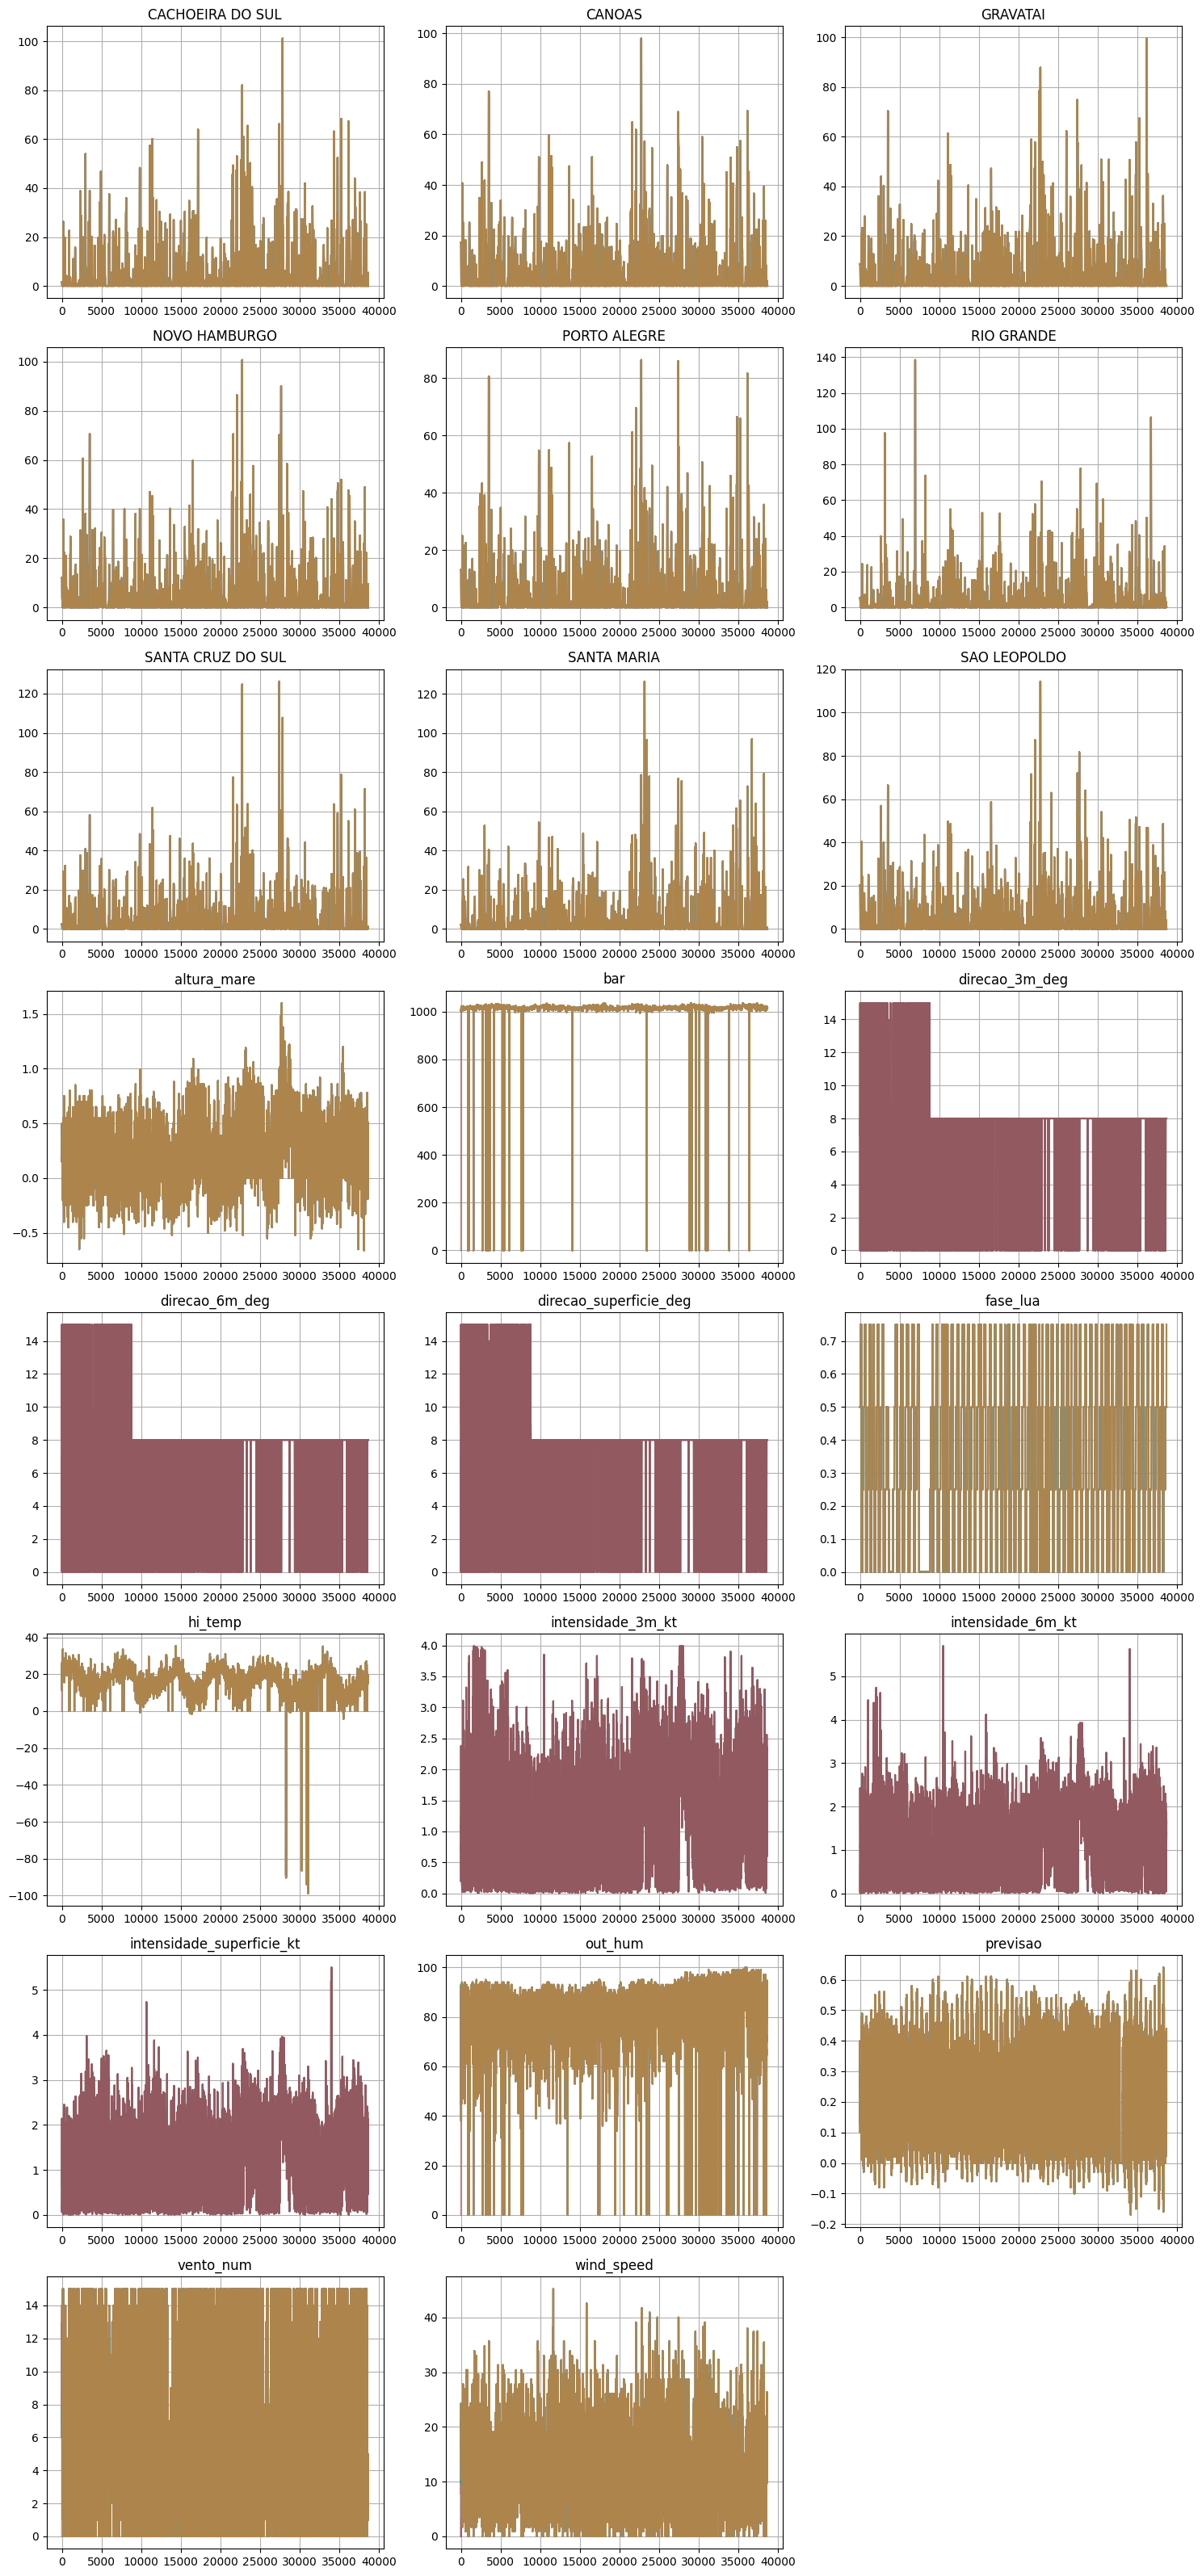

In [6]:

base_vars = sorted(set(c.split("_lag")[0].split("_lead")[0] for c in X_o.columns))

n_cols = 3
n_rows = int(np.ceil(len(base_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(base_vars):
    related_cols = [c for c in X_o.columns if c.startswith(var)]

    for col in related_cols:
        axes[i].plot(X_o.index, X_o[col], alpha=0.6)

    axes[i].set_title(var)
    axes[i].grid(True)

# remover vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

(30928, 240)
(7733, 240)


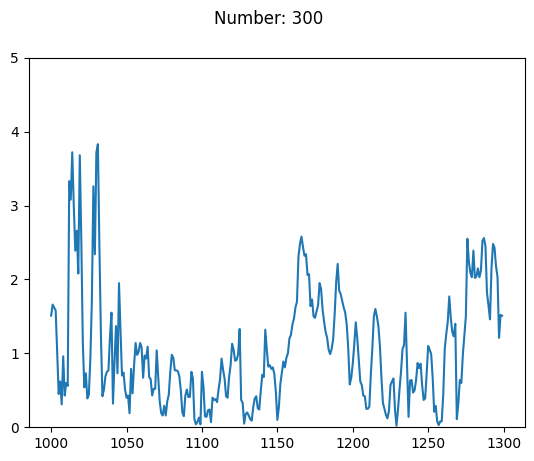

In [7]:

# =========================
# SPLIT (80/20 temporal)
# =========================
def normalize_minmax(X):
    X = np.array(X, dtype=np.float32)
    min_vals = X.min(axis=0)
    max_vals = X.max(axis=0)

    denom = max_vals - min_vals
    denom[denom == 0] = 1.0

    X_norm = (X - min_vals) / denom
    return X_norm, min_vals, max_vals




split = int(len(X_o) * 0.8)
trainX, testX = X_o.iloc[:split], X_o.iloc[split:]
trainY, testY = y.iloc[:split], y.iloc[split:]

print(trainX.shape)
print(testX.shape)

# =========================
# VISUALIZAÇÃO
# =========================

plttam = 300
plt.ylim([0, 5])
plt.plot(range(1000,1000+plttam), trainY.iloc[1000:1000+plttam])
plt.suptitle('Number: ' + str(plttam))
plt.show()

# =========================
# CONFIG
# =========================

USE_NORMALIZATION = False

# =========================
# SPLIT (80/20 temporal)
# =========================

split = int(len(X_o) * 0.92)
trainX, testX = X_o.iloc[:split], X_o.iloc[split:]
trainY, testY = y.iloc[:split], y.iloc[split:]

# =========================
# LIMPEZA NUMÉRICA FINAL
# =========================

trainX = np.nan_to_num(trainX.to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)
testX  = np.nan_to_num(testX.to_numpy(),  nan=0.0, posinf=0.0, neginf=0.0)

trainY = np.nan_to_num(trainY.to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)
testY  = np.nan_to_num(testY.to_numpy(),  nan=0.0, posinf=0.0, neginf=0.0)

# =========================
# NORMALIZAÇÃO (CONDICIONAL)
# =========================

if USE_NORMALIZATION:
    # X
    trainX, min_vals, max_vals = normalize_minmax(trainX)
    testX = (testX - min_vals) / (max_vals - min_vals + 1e-8)

    # Y
    trainY, minY, maxY = normalize_minmax(trainY)
    testY = (testY - minY) / (maxY - minY + 1e-8)

else:
    # mantém dados originais
    min_vals, max_vals = None, None
    minY, maxY = None, None

In [8]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=1e-4)
trainX = selector.fit_transform(trainX)
testX = selector.transform(testX)

In [9]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# ========================
# Função de acurácia
# ========================
def acuracia_intensidade_raw(y_true, y_pred, threshold=0.5):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    erro = np.abs(y_true - y_pred)
    acc = np.mean(erro < threshold) * 100
    return round(acc, 3)

# ========================
# Espaço de busca (expandido)
# ========================
param_dist = {
    'n_estimators': [100],
    'max_depth': [8, 10, 12, 15, 20, None],
    'min_samples_split': [2, 5, ],
    'min_samples_leaf': [1, 2, ],
    'max_features': ['sqrt', 'log2', 0.3]
}

# ========================
# Validação temporal
# ========================
tscv = TimeSeriesSplit(n_splits=5)

# ========================
# Random Search (mais combinações)
# ========================
search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=60,  # aumentado (mais combinações)
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(trainX, trainY)

# Melhor modelo encontrado
model = search.best_estimator_

print("\nMelhores parâmetros encontrados:")
print(search.best_params_)

# ========================
# Avaliação por fold com métrica customizada
# ========================
accuracies = []

for i, (train_idx, test_idx) in enumerate(tscv.split(trainX)):
    X_train_fold, X_test_fold = trainX[train_idx], trainX[test_idx]
    y_train_fold, y_test_fold = trainY[train_idx], trainY[test_idx]

    model.fit(X_train_fold, y_train_fold)
    y_pred_fold = model.predict(X_test_fold)

    acc = acuracia_intensidade_raw(y_test_fold, y_pred_fold)
    accuracies.append(acc)

    print(f"Fold {i+1} - Acurácia (erro < 0.5): {acc}%")

acc_media = np.mean(accuracies)

print(f"\nAcurácia média: {round(acc_media, 3)}%")

# ========================
# Opcional: salvar tudo
# ========================
resultados = {
    "accuracies_por_fold": accuracies,
    "acuracia_media": round(acc_media, 3),
    "melhores_parametros": search.best_params_
}

Fitting 5 folds for each of 60 candidates, totalling 300 fits


KeyboardInterrupt: 

In [ ]:
samples_per_day = 24   # hourly data
# or 48, 96, etc depending on your frequency
import numpy as np
import matplotlib.pyplot as plt

def plot_random_days(
    y_true,
    y_pred,
    samples_per_day,
    n_days=10
):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)

    total_days = len(y_true) // samples_per_day

    # avoid overflow
    max_day_start = total_days - 1

    # pick random days
    days = np.random.choice(max_day_start, size=n_days, replace=False)

    fig, axes = plt.subplots(n_days, 1, figsize=(12, 3 * n_days))

    if n_days == 1:
        axes = [axes]

    for i, d in enumerate(days):
        start = d * samples_per_day
        end = start + samples_per_day

        real = y_true[start:end]
        pred = y_pred[start:end]

        axes[i].plot(real, label="Real")
        axes[i].plot(pred, label="Predicted")

        axes[i].set_title(f"Day index: {d}")
        axes[i].grid(True)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
plot_random_days(
    testY,
    pred_test,
    samples_per_day=24,   # adjust to your data
    n_days=10
)